**Packages**

In [1]:
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Bidirectional
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)

**Helper Functions**

In [2]:
class LSTMModel:
    def __init__(self, model, name):
            self.model = model
            self.name = name

def get_lstm_model(input_shape) -> LSTMModel:
    """
        Returns  lstm model for training, reduces redundant code.
    """
    bilstm_model = Sequential()
    bilstm_model.add(Bidirectional(LSTM(128, return_sequences=False), input_shape=input_shape))
    bilstm_model.add(Dropout(0.2))
    bilstm_model.add(Dense(64, activation='relu'))
    bilstm_model.add(Dense(1))
    bilstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

    return LSTMModel(bilstm_model, 'BiLSTM Neural Network')


In [5]:
def calculate_metrics(y_test, y_pred) -> None:
    """ 
        Function to evaluate the model that returns pandas.Dataframe object.
    """
    mse = mean_squared_error(y_pred, y_test)
    mae = mean_absolute_error(y_pred, y_test)
    r2 = r2_score(y_pred, y_test)

    res = pd.DataFrame({
        "MSE": [mse],
        "MAE": [mae],
        "R2": [r2]
    })

    print(res)

In [6]:
def plot_results(y_test, y_preds, model: str) -> None:
    """
    Plots the results of training a model.
    Handles both pandas Series and numpy arrays, and LSTM or tree models.
    """
    y_test_plot = y_test.values if hasattr(y_test, 'values') else y_test
    y_preds_plot = y_preds.values if hasattr(y_preds, 'values') else y_preds

    plt.figure(figsize=(10,5))
    plt.plot(y_test_plot, label='Actual', color='blue')
    plt.plot(y_preds_plot, label=f'{model} Predictions', color='red')
    plt.title(f"{model} predictions on gold prices")
    plt.legend()
    plt.show()

In [15]:
class XGBModel:
    def __init__(self, model, name):
        self.model = model
        self.name = name 

def get_xgb_model() -> XGBModel:
    model = XGBRegressor(
    n_estimators=500,      
    learning_rate=0.05,     
    max_depth=5,           
    subsample=0.8,          
    colsample_bytree=0.8,   
    random_state=42,        
    objective="reg:squarederror"  
    )
    return XGBModel(model, "XGBRegressor")

**Loading dataset**

In [3]:
path = 'indicators-mega-gold-dataset.csv'
df = pd.read_csv(path, parse_dates=['Date'])
df.head()

,Date,Gold_Price,Crude_Oil,Inflation,Interest_Rate,USD_EUR,USD_JPY,SLV,^GSPC,sentiment_enc,up_down_flag,day_count,cum_drop,indicator
0,2019-12-02,0.001751,0.468993,0.04576,0.284091,0.544606,0.110961,0.223575,0.227485,0.0,0,0,0.000000,0.000000
1,2019-12-03,0.012758,0.468993,0.04576,0.284091,0.549832,0.101503,0.235753,0.222120,0.0,1,0,0.000000,0.000000
2,2019-12-04,0.011174,0.468993,0.04576,0.284091,0.544979,0.107245,0.221627,0.227197,0.0,0,1,0.001366,0.001366
3,2019-12-05,0.011841,0.468993,0.04576,0.284091,0.555431,0.104205,0.226011,0.228409,0.0,1,0,0.000000,0.000000
4,2019-12-06,0.000333,0.468993,0.04576,0.284091,0.536021,0.103699,0.207988,0.235801,1.0,0,1,0.009928,0.009928


**Dividing in subsets**

In [4]:
feature_cols = [col for col in df.columns if col not in ['Date', 'Gold_Price']]
target_col = 'Gold_Price'

split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train = train_df[feature_cols].values
y_train = train_df[target_col].values
X_test = test_df[feature_cols].values
y_test = test_df[target_col].values

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

lstm = get_lstm_model((X_train_lstm.shape[1], X_train_lstm.shape[2]))
model = lstm.model
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_lstm, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=2
)

c:\Users\User\dev\training_model\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
29/29 - 5s - 189ms/step - loss: 0.0139 - val_loss: 0.0039
Epoch 2/100
29/29 - 0s - 8ms/step - loss: 0.0057 - val_loss: 0.0023
Epoch 3/100
29/29 - 0s - 8ms/step - loss: 0.0047 - val_loss: 0.0019
Epoch 4/100
29/29 - 0s - 9ms/step - loss: 0.0042 - val_loss: 0.0018
Epoch 5/100
29/29 - 0s - 9ms/step - loss: 0.0038 - val_loss: 0.0021
Epoch 6/100
29/29 - 0s - 9ms/step - loss: 0.0037 - val_loss: 9.3360e-04
Epoch 7/100
29/29 - 0s - 10ms/step - loss: 0.0035 - val_loss: 8.4338e-04
Epoch 8/100
29/29 - 0s - 9ms/step - loss: 0.0031 - val_loss: 0.0017
Epoch 9/100
29/29 - 0s - 9ms/step - loss: 0.0029 - val_loss: 0.0041
Epoch 10/100
29/29 - 0s - 10ms/step - loss: 0.0028 - val_loss: 0.0012
Epoch 11/100
29/29 - 0s - 9ms/step - loss: 0.0025 - val_loss: 0.0023
Epoch 12/100
29/29 - 0s - 9ms/step - loss: 0.0021 - val_loss: 0.0027
Epoch 13/100
29/29 - 0s - 9ms/step - loss: 0.0020 - val_loss: 0.0023
Epoch 14/100
29/29 - 0s - 11ms/step - loss: 0.0019 - val_loss: 0.0037
Epoch 15/100
29/29 - 0s - 12ms

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
        MSE       MAE        R2
0  0.053293  0.207673 -7.562365


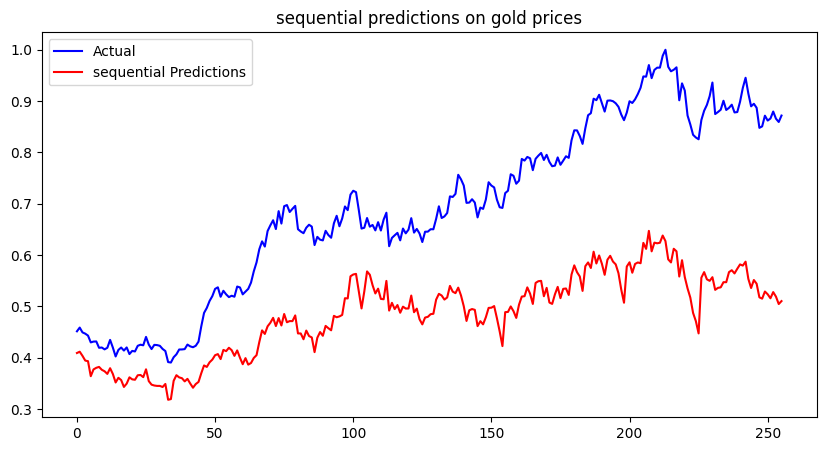

In [7]:
y_pred = model.predict(X_test_lstm)


calculate_metrics(y_test, y_pred)
plot_results(y_test, y_pred, model.name)

**New dataframe**

In [13]:
new_df = pd.DataFrame({
    "y_pred": y_pred.ravel(),
    "actual": y_test
})

new_df.head()

,y_pred,actual
0,0.409179,0.451468
1,0.411733,0.458722
2,0.403674,0.449383
3,0.394451,0.446881
4,0.393237,0.443129


        MSE       MAE          R2
0  0.104477  0.296557 -698.624023


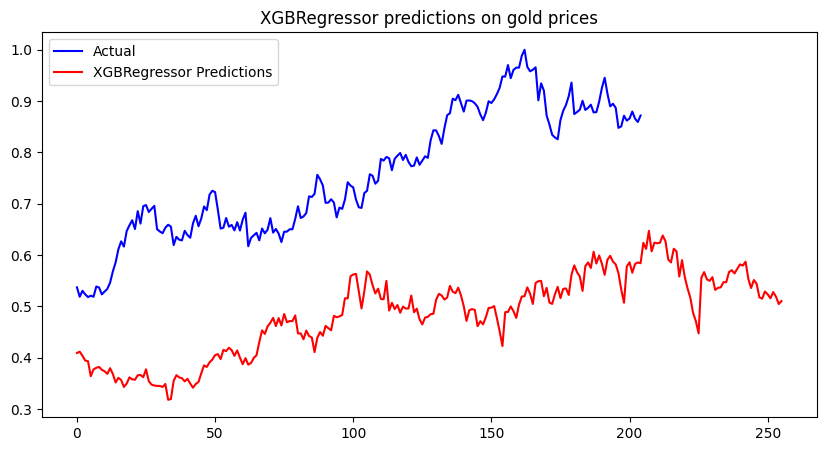

In [20]:
xgb = get_xgb_model()
model = xgb.model

X = new_df[['y_pred']]
y = new_df['actual']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.2, shuffle=False)

model.fit(X_train, y_train)

y_preds = model.predict(X_test)

calculate_metrics(y_test, y_preds)
plot_results(y_test, y_pred, xgb.name)